# ⛪️ Data Layer — Religious Institutions in Berlin

---

# Final Documentation Summary  
### Religious Institutions Data Layer — Cleaning, Transformation & Mapping

This section documents all the major processing steps performed during the transformation of the Religious Institutions dataset, including enrichment, standardization, spatial integration, and preparation for database loading.

---
## ERD Update

The Religious Institutions table was added to the official Berlin Source ERD.

Below is the updated section showing the new table and its relationship with `districts`:

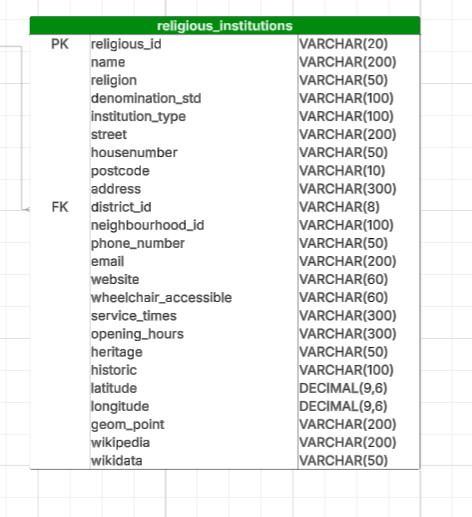

---
## 🔧 1. Cleaning Steps

### **1.1 Missing Data Handling**
- Identified missing values across all columns and quantified completeness.
- Address enrichment performed **only for rows lacking street, postcode, and suburb**, using:
  - **Nominatim** (primary reverse geocoder, throttled and cached)
  - **Photon** (fallback for sparse results)
- A caching system ensured API rate-limits were respected and eliminated repeated lookups.
- `address` column constructed from all available parts (street, house number, suburb, district, postcode, country).

### **1.2 Column Name Normalization**
- Standardized naming conventions according to Berlin Data Platform schema.
- Converted geometry to correct CRS (`EPSG:4326`).

### **1.3 Duplicate & Geometry Validation**
- Verified uniqueness of `religious_id`.
- Ensured all points fall within Berlin’s expected latitude/longitude bounding box.
- Confirmed validity of `geom_point` geometry.
- Removed any rows missing `district_id` or `neighbourhood_id`.

---

## 🔄 2. Transformation Steps

### **2.1 Denomination Normalization**
- Consolidated raw denomination values into a unified standardized field `denomination_std`.
- Applied logic:
  - If `religion == 'christian'` and `denomination` is null → assign `general_christian`.
  - Otherwise map raw denominations using curated dictionary.

### **2.2 Institution Type Classification**
- Derived from OSM tag `building=*`.
- Standardized into internal `institution_type` taxonomy:
  - `church`, `mosque`, `synagogue`, `temple`, `chapel`, …
- Handled ambiguous values:
  - `yes` → converted to `place_of_worship`

### **2.3 Address Standardization**
- Structured address components stored individually:
  - `street`, `housenumber`, `postcode`, `suburb`
- Constructed `address` as human-readable combined field.
- Replaced empty strings or whitespace with `NaN`.

---

## 🗺️ 3. Spatial Mapping Steps

### **3.1 District Assignment**
- Spatial join with `lor_ortsteile.geojson`:
  - `district` from `BEZIRK`
  - `neighborhood` (Ortsteil) from `OTEIL`
- Ensured all geometries were valid Points before joining.

### **3.2 Adding District IDs**
- Mapped district names to official Berlin statistical region IDs  
  (source: *regionalstatistik.de*).
- Created column `district_id` as 8-digit string.

### **3.3 Adding Neighbourhood IDs**
- Used `spatial_name` from LOR dataset as the official identifier.
- `neighborhood_id` derived using the same column used in Pharmacy example.

### **3.4 Reference**
- Mapping documentation from GitHub:  
  https://github.com/webeet-io/layered-populate-data-pool-da/tree/main/mapping

---

## 📊 4. Assumptions & Data Quality Notes

### **4.1 Address Enrichment Assumptions**
- Nominatim results take precedence; Photon used only as fallback.
- If both geocoders fail → values remain `NaN`.
- OSM sometimes omits house numbers; this is expected and not treated as an error.

### **4.2 Religion & Denomination Assumptions**
- Some Christian institutions omit denomination → assigned `general_christian`.
- Multi-denomination strings (e.g., `"lutheran;rum-orthodox"`) treated as invalid → mapped to most dominant category or left as original string if unclear.

### **4.3 Geometry Limitations**
- OSM provides polygons for some institutions; these were converted to centroid Points for stable joins.
- Geometry stored as WKT text for compatibility with Neon (no PostGIS extension).

### **4.4 Data Completeness Observations**
- Contact info (email, phone) missing in >90% cases → preserved.
- Heritage/historic fields sparsely populated → preserved.

---

## 🧱 5. Constraints & Reference Design Justification

### **Why Foreign Key to `districts` Table?**
- Ensures referential integrity across all layers.
- Allows frontend filtering and spatial drill-down.
- Guarantees consistency with other datasets (pharmacies, galleries, etc.).

#### **Why `ON DELETE RESTRICT`?**
- Prevents accidental deletion of districts that still contain institutions.

####  **Why `ON UPDATE CASCADE`?**
- Automatically updates child rows if district IDs ever change.

####  **Why Use Text Instead of Spatial Type?**
- Neon does not support PostGIS by default.
- WKT storage ensures maximum portability and avoids geometry errors during insert.

---

## ✅ Final Output Ready for Upload

- All records cleaned and validated
- Fully standardized schema
- Spatially enriched (district + neighborhood + IDs)
- Geometries converted to WKT
- Ready for database creation + insertion

---

## 🧪 Step 1: Research & Data Modelling

### 🎯 Objective
The goal of Step 1 was to identify and document reliable data sources for religious institutions in Berlin.
This step focused on discovering, collecting, and evaluating datasets suitable for integration into the Berlin data foundation.

---

### 🧩 Tasks Completed

- Created branch **`religious-institutions-data-modelling`** and directory structure:

/religious_institutions/ \
└── sources/ 

- Retrieved base data from **OpenStreetMap (Overpass API)** with `amenity=place_of_worship`
- Loaded data into a GeoDataFrame using **GeoPandas**
- Inspected dataset structure and identified relevant fields
- Extracted the following key columns for modelling:

id, name, religion, denomination, building, address fields,
contact info, wheelchair, service_times, opening_hours,
heritage, historic, geometry, latitude, longitude, source 

- Exported raw data in both `.csv` and `.geojson` format into `/sources`
- Created a detailed `README.md` inside `/sources` documenting:
- Data source origin and update frequency
- Relevant data fields
- Transformation plan for Step 2

---

### ✅ Outcome
A validated and documented dataset from **OpenStreetMap** with 754 entries
representing various religious institutions (churches, mosques, temples, synagogues, etc.) across Berlin.  
These data now serve as the foundation for Step 2: **Transformation & Preprocessing.**

---

### Imports

In [1]:
import osmnx as ox # to fetch data from OpenStreetMap
import geopandas as gpd # to work with geospatial data
import requests, pandas as pd # to work with tabular data
import os, json, time, random, re # for file handling, caching, delays, and randomness
import numpy as np # for numerical operations
from geopy.geocoders import Nominatim, Photon
from geopy.extra.rate_limiter import RateLimiter
from tqdm.auto import tqdm
from shapely.geometry import Point
from sqlalchemy import create_engine, text
import warnings
import psycopg2
from shapely.geometry import Point, Polygon

warnings.filterwarnings("ignore")

### 1.1 Data Source Discovery
Conduct initial research to identify relevant data sources for religious institutions (e.g., churches, mosques, temples, synagogues).

In [3]:
# Fetch religious institutions data from OpenStreetMap for Berlin, Germany
tags = {"amenity": "place_of_worship"}
religious_gdf = ox.features_from_place("Berlin, Germany", tags)

In [4]:
religious_gdf.describe(include='all').T

,count,unique,top,freq
geometry,754,754,POINT (13.3587758 52.5347753),1
amenity,754,1,place_of_worship,754
check_date,246,200,2025-10-19,5
name,719,629,Neuapostolische Kirche,10
religion,750,8,christian,649
...,...,...,...,...
layer,1,1,-2,1
location,1,1,surface,1
name:la,1,1,Sanctissimum Corpus Christi,1
landuse,1,1,cemetery,1


## 1.2 Modelling & Planning

Select and define the key attributes relevant to this layer. \
Example fields:

- Institution name
- Denomination (e.g., Christian, Muslim, Jewish, Hindu, Buddhist, etc.)
- Sub-type (church, mosque, synagogue, temple, chapel, prayer hall, etc.)
- Address
- District
- Neighborhood
- Contact info (phone, email, website)
- Opening hours / prayer times (if available)
- Geolocation (lat/lon)
- Historical or cultural significance (if available)
- Wikidata, Wikipedia

In [5]:
religious_gdf = religious_gdf.to_crs(epsg=4326)  # WGS84

In [76]:
gdf = religious_gdf.copy()

# 1) Make sure the CRS is WGS84 (EPSG:4326)
if gdf.crs is None:
    gdf = gdf.set_crs(epsg=4326)
else:
    gdf = gdf.to_crs(epsg=4326)

# 2) Checks on geometry types
print(gdf.geom_type.value_counts(dropna=False).head())

# 3) Extract representative point for each geometry 
def to_point(geom):
    if geom is None or geom.is_empty:
        return None
    if geom.geom_type == "Point":
        return geom
    # For other geometry types, get a representative point
    try:
        return geom.representative_point()
    except Exception:
        # Fallback to centroid if representative_point fails
        return geom.centroid

gdf["geom_point"] = gdf.geometry.apply(to_point)
gdf = gdf[~gdf["geom_point"].isna()].copy()

# 4) Extracts Longitude/Latitude (x = lon, y = lat)
gdf["longitude"] = gdf["geom_point"].x
gdf["latitude"]  = gdf["geom_point"].y


# Final check of selected columns
gdf[["name","amenity","religion","denomination","latitude","longitude"]].head()

Polygon         563
Point           190
MultiPolygon      1
Name: count, dtype: int64


name  \
element id                                                            
node    29040731                                 Sultan Ahmed Camii   
        29209127   Kirchhof Jerusalem und Neue Kirche I, II und III   
        248702772                             Martin-Luther-Kapelle   
        289795838                                       St. Wilhelm   
        292201931             Stadtmission Gemeinde Friedrichshagen   

                            amenity   religion denomination   latitude  \
element id                                                               
node    29040731   place_of_worship     muslim          NaN  52.534775   
        29209127   place_of_worship  christian          NaN  52.495182   
        248702772  place_of_worship  christian   protestant  52.601020   
        289795838  place_of_worship  christian     catholic  52.522507   
        292201931  place_of_worship  christian   protestant  52.447500   

                   longitude  
element id                    
node    29040731   13.358776  
        29209127   13.390379  
        248702772  13.296617  
        289795838  13.195419  
        292201931  13.623567

In [78]:
# Reset index to get the OSM IDs as a column
gdf = gdf.reset_index()

In [79]:
gdf.head()

,index,element,id,geometry,amenity,check_date,name,religion,wheelchair,denomination,...,name:et,reconstruction_date,layer,location,name:la,landuse,type,geom_point,longitude,latitude
0,0,node,29040731,POINT (13.35878 52.53478),place_of_worship,2024-08-01,Sultan Ahmed Camii,muslim,yes,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,POINT (13.35878 52.53478),13.358776,52.534775
1,1,node,29209127,POINT (13.39038 52.49518),place_of_worship,NaN,"Kirchhof Jerusalem und Neue Kirche I, II und III",christian,limited,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,POINT (13.39038 52.49518),13.390379,52.495182
2,2,node,248702772,POINT (13.29662 52.60102),place_of_worship,2024-10-03,Martin-Luther-Kapelle,christian,NaN,protestant,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,POINT (13.29662 52.60102),13.296617,52.601020
3,3,node,289795838,POINT (13.19542 52.52251),place_of_worship,2025-08-13,St. Wilhelm,christian,NaN,catholic,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,POINT (13.19542 52.52251),13.195419,52.522507
4,4,node,292201931,POINT (13.62357 52.4475),place_of_worship,NaN,Stadtmission Gemeinde Friedrichshagen,christian,NaN,protestant,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,POINT (13.62357 52.4475),13.623567,52.447500


### - Creating New Table with Selected Columns

In [80]:
# Selected columns to keep
keep_cols = [
    "id", "name", "religion", "denomination", "building",
    "addr:street", "addr:housenumber", "addr:postcode", "addr:suburb", "addr:city",
    "operator", "website", "contact:phone", "contact:email",
    "wheelchair", "service_times", "opening_hours","heritage", "historic", "geometry",
    "geom_point", "latitude", "longitude", "source", "wikidata", "wikipedia"
]
gdf = gdf[keep_cols]

In [81]:
# Rename map for only the columns that need renaming

rename_map = {
    "id": "religious_id",
    "addr:street": "street",
    "addr:housenumber": "housenumber",
    "addr:postcode": "postcode",
    "addr:suburb": "suburb",
    "addr:city": "city",
    "addr:country": "country",
    "opening_hours": "opening_hours",
    "wheelchair": "wheelchair_accessible",
    "building": "building_type",
    "contact:phone": "contact_phone",
    "contact:email": "contact_email"
}

In [82]:
gdf = gdf.rename(columns=rename_map)

### - Checking Missing Values

In [83]:
# Count total number of missing values per column
missing_count = gdf.isna().sum().sort_values(ascending=False)

In [84]:
# Count total number of rows
row_count = len(gdf)
print(row_count)

754


Here we can see that there is 4 values missing in religion and one extra labeled as *none*. These cases have to be investigaded in the next step.

In [85]:

# Build table with counts and % of missing values
# This is important to understand data quality - so we can drop the columns with too many missing values

missing = pd.DataFrame({
    "missing_count": missing_count,
    "missing_pct": (missing_count / row_count * 100).round(1)
}).sort_values(by="missing_pct", ascending=False)

print(missing)

                       missing_count  missing_pct
historic                         747         99.1
contact_email                    722         95.8
opening_hours                    713         94.6
contact_phone                    702         93.1
operator                         652         86.5
source                           629         83.4
service_times                    618         82.0
heritage                         553         73.3
website                          452         59.9
wikipedia                        440         58.4
wikidata                         375         49.7
wheelchair_accessible            372         49.3
suburb                           354         46.9
housenumber                      261         34.6
postcode                         228         30.2
street                           225         29.8
city                             220         29.2
building_type                    193         25.6
denomination                     148         19.6


### - Distinct Values per Column

In [86]:
# Number of unique values per column
# Goal: See the “variety” of each column.

distinct = gdf.nunique().sort_values(ascending=False)
print(distinct)

religious_id             754
longitude                754
geom_point               754
geometry                 754
latitude                 753
name                     629
street                   447
wikidata                 379
wikipedia                314
website                  283
housenumber              198
postcode                 169
suburb                    88
operator                  87
service_times             68
contact_phone             52
denomination              50
opening_hours             40
contact_email             32
source                    20
building_type             15
religion                   8
wheelchair_accessible      3
heritage                   2
historic                   2
city                       1
dtype: int64


### - Most Common Values per Column

In [87]:
# Example: top 10 religions
print("\nTop 10 religions:")
print(gdf["religion"].value_counts().head(10))


Top 10 religions:
religion
christian        649
muslim            67
buddhist          16
jewish             8
hindu              6
multifaith         2
happy_science      1
none               1
Name: count, dtype: int64


In [88]:
print("\nTop 10 denominations:")
print(gdf["denomination"].value_counts().head(10))


Top 10 denominations:
denomination
protestant          273
roman_catholic       77
catholic             41
lutheran             30
baptist              26
pentecostal          16
new_apostolic        16
evangelical          13
jehovahs_witness     12
methodist            11
Name: count, dtype: int64


In [89]:
print("\nTop 10 streets:")
print(gdf["street"].value_counts().head(10))


Top 10 streets:
street
Hauptstraße               7
Richardstraße             5
Karl-Marx-Straße          4
Müllerstraße              4
Friedenstraße             4
Waldstraße                3
Hermannstraße             3
Kurfürstenstraße          3
Seeburger Straße          3
Reinickendorfer Straße    3
Name: count, dtype: int64


In [90]:
# Example: most common postcode 
print("\nTop 10 postcodes:")
print(gdf["postcode"].value_counts().head(10))


Top 10 postcodes:
postcode
13357    9
13507    8
10999    7
13088    7
14109    7
10115    7
13359    7
13509    6
12107    6
12043    6
Name: count, dtype: int64


In [64]:
# Example: most common opening_hours
print("\nTop 10 opening hours:")
print(gdf["opening_hours"].value_counts().head(10))


Top 10 opening hours:
opening_hours
08:00-18:00                                                                                         2
11:00-18:00                                                                                         1
Mar Su[-1]-Oct Su[-1] - 1 day Mo-Su 14:00-17:00, Oct Su[-1]-Mar Su[-1] - 1 day Mo-Su 14:00-16:00    1
Mo,Fr,So 15:00-17:00                                                                                1
Th 12:00-18:00                                                                                      1
Mo-Fr 11:30-12:30                                                                                   1
We 12:00-15:00                                                                                      1
We 16:00-19:00                                                                                      1
Mo-Su 08:00-19:00                                                                                   1
Mo,We,Th,Fr 10:00-14:00; Tu 10:00-13:00      

In [65]:
# Example: most common service times
print("\nTop 10 service times:")
print(gdf["service_times"].value_counts().head(10))


Top 10 service times:
service_times
Su 10:00                          35
Su 11:00                          17
Su 10:30                          11
Su 15:00                           3
Su 10:00-11:00                     2
Su 10:30-12:30                     2
Su 9:30                            2
Su 09:30; We 19:30                 2
Th 19:00-20:45, Su 10:00-11:45     2
Su 09:30                           2
Name: count, dtype: int64


In [66]:
# Example : most commmon building type
print("\nTop 10 building types:")
print(gdf["building_type"].value_counts().head(10))


Top 10 building types:
building_type
church          374
yes              99
chapel           54
mosque            9
kingdom_hall      5
residential       4
synagogue         3
apartments        3
religious         3
cathedral         2
Name: count, dtype: int64


In [67]:
# Example: most common wheelchair accessible
print("\nHow many institutions have wheelchair accessibility:")
print(gdf["wheelchair_accessible"].value_counts().head(10))


How many institutions have wheelchair accessibility:
wheelchair_accessible
yes        194
limited    100
no          88
Name: count, dtype: int64


In [68]:
# Goal: Verify lat/lon look realistic.
# Why? If values are way off, something went wrong in conversion.

print("Latitude range:", gdf["latitude"].min(), "to", gdf["latitude"].max())

print("Longitude range:", gdf["longitude"].min(), "to", gdf["longitude"].max())

Latitude range: 52.375495400000005 to 52.64227125
Longitude range: 13.117642455614089 to 13.722686518291663


## 1.3 Prepare the /sources Directory

- Raw Data Files:

    - religions_raw.geojson (includes geometry)
    - religions_raw.csv (tabular only, no geometry)
- README.md in /sources will contain:

    - Data sources used.
    - Planned transformation steps.

In [69]:
os.chdir(os.path.join(os.path.expanduser("~"), "Downloads"))
os.getcwd()

'/Users/marcellavalenteralser/Downloads'

In [27]:
# Define file paths
raw_geojson_path = "religions_raw.geojson"
raw_csv_path = "religions_raw.csv"

In [ ]:
# Save as GeoJSON (keeps geometry) and CSV

gdf.to_file(raw_geojson_path, driver="GeoJSON")
gdf.drop(columns="geom_point").to_csv(raw_csv_path, index=False)

print(f"Raw data saved to: {raw_geojson_path} and {raw_csv_path}")

# 🧭 Religious Institutions Data Layer – Step 2: Data Transformation & Preprocessing

## 🎯 Objective
The goal of Step 2 is to enrich, standardize, and clean the dataset of religious institutions in Berlin
to produce a unified, validated version ready for database integration.

---

## 🧩 Workflow 

### 1. Manual Enrichment
- Manually verify and complete information for institutions with missing `religion`, `denomination`, or unclear `type`.
- Cross-check coordinates and details via OpenStreetMap, Google Maps, and official directories.
- Verified entries:
  1. Pura Tri Hita Karana (Hindu temple)  
  2. Evangelischer Friedhof Blankenburg  
  3. Lazarus-Kapelle (Mitte)  
  4. Fontane-Gedenkstätte  
  5. Evangelischer Friedhof Schmargendorf


### 2. Address Enrichment (Nominatim)
- Use **Geopy Nominatim** to complete missing address components:
  - street  
  - housenumber  
  - postcode  
  - suburb  
  - borough  
  - country
- Combine these fields into a single formatted address string.
- Only query rows with missing address data to avoid API rate limits.


### 3. Data Cleaning
- Analyze missing values across all columns.  
- Remove columns with > 85 % missing data (unless useful for metadata).  
- Drop irrelevant or redundant columns (e.g., `city`, `country`, `source`).
- Remove duplicates and invalid geometry.
- Standardize column names and ensure consistent formats.

### 4. Geospatial Validation
- Confirm CRS: **EPSG:4326 (WGS 84)**.  
- Verify all geometries are of type `Point`.  
- Ensure `latitude` and `longitude` match the geometry values.

### 5. Standardization & Transformation
- Normalize categorical fields:
  - `religion` → all lowercase  
  - `denomination` → unified spelling (e.g., *roman_catholic*, *protestant*, *sunni*)  
- Derive `type_of_institution` based on the `building` or `type` field.  
- Align column names with the **target schema** (e.g., `street`, `postcode`, `borough`, etc.).

### 6. Spatial Integration

- **Load districts:** Imported official Berlin boundaries from `lor_ortsteile.geojson`.  
- **Perform spatial join:** Matched each institution’s point geometry to the corresponding *Ortsteil* polygon using `predicate="within"`.  
- **Rename columns:** Renamed `BEZIRK` → `district` and `OTEIL` → `neighbourhood` for clarity.  
- **Add district IDs:** Mapped each district to its official statistical ID (`district_id`) based on the Berlin Regional Statistics reference.  
- **Replace only missing values:** Populated district fields only where `borough` was missing, without overwriting valid data.  

### 7. Export & Documentation
- Export cleaned and unified dataset:
  - `religious_institutions_unified_data.csv`
- Include clear Markdown documentation:
  - Summary of enrichment and cleaning steps  
  - Data quality notes  
  - Limitations and assumptions  

---

## ✅ Expected Output
A single, enriched, and standardized dataset containing all religious institutions in Berlin,
including both automatically and manually enriched entries,
ready for loading into the Berlin Data Foundation database.

---

### 1. Manual Enrichment Summary

During the data cleaning phase, five entries were manually reviewed and enriched using reliable public sources such as  
[OpenStreetMap](https://www.openstreetmap.org), [Google Maps](https://maps.google.com), and  
the [Evangelische Friedhöfe Berlin](https://www.evangelische-friedhoefe-berlin.de) directory.

These enrichments were applied to handle missing or incomplete information, especially for institutions where
religion, denomination, or address data were absent or unclear.

---

#### 🔧 Overview of Manual Updates

| Religious ID | Name | Type | Religion | Denomination | Borough | Source / Notes |
|---------------|------|------|-----------|---------------|----------|----------------|
| **9592974541** | Pura Tri Hita Karana | temple | hindu | balinese | Marzahn-Hellersdorf | Identified as Balinese Hindu temple located at Eisenacher Str. 100, 12685 Berlin |
| **4362191535** | Evangelischer Friedhof Blankenburg | cemetery | christian | protestant | Pankow | Verified via Evangelische Friedhöfe Berlin; no house number assigned |
| **53258071** | Lazarus-Kapelle (Diakoniestiftung Lazarus) | chapel | christian | evangelical | Mitte | Located within Lazarus Diaconal Foundation complex; services held on Sundays |
| **1203293667** | Fontane-Gedenkstätte (Dorotheenstädtischer Friedhof II) | memorial | christian | protestant | Mitte | Part of Dorotheenstädtischer Friedhof II; Protestant cemetery; marks Theodor Fontane’s grave |
| **368207487** | Evangelischer Friedhof Schmargendorf | cemetery | christian | protestant | Charlottenburg-Wilmersdorf | Identified as Evangelischer Friedhof Schmargendorf; Protestant cemetery complex verified manually |

---

#### 🧠 Notes

- All five entries were verified via **geolocation checks and public databases**.  
- Missing values were filled **only where verifiable**; unconfirmed attributes remain `NaN`.  
- The enrichment followed the project’s policy of **transparent manual documentation** for traceability.  
- Each entry includes a short note explaining the reasoning and data source used.

---

✅ **Result:**  
The manual enrichment ensures that all relevant religious institutions in Berlin are now properly categorized,
improving data completeness without compromising accuracy.

In [ ]:
gdf.loc[gdf['religion'].isna()]

,religious_id,name,religion,denomination,building_type,street,housenumber,postcode,suburb,city,...,opening_hours,heritage,historic,geometry,geom_point,latitude,longitude,source,wikidata,wikipedia
95,4362191535,Friedhof von ehem. Insassen des NS-Zwangsarbei...,NaN,NaN,NaN,Ilsenburgstraße,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,POINT (13.44755 52.59383),POINT (13.44755 52.59383),52.593826,13.447549,NaN,NaN,NaN
160,9592974541,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,POINT (13.57793 52.53946),POINT (13.57793 52.53946),52.539463,13.577931,NaN,NaN,NaN
456,53258071,Lazarus Kapelle,NaN,NaN,chapel,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,"POLYGON ((13.38876 52.53512, 13.38875 52.53512...",POINT (13.38883 52.53502),52.535016,13.388827,NaN,NaN,NaN
752,1203293667,Fontane-Gedenkstätte,NaN,NaN,yes,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,"POLYGON ((13.37802 52.53805, 13.37808 52.53808...",POINT (13.37809 52.53804),52.538039,13.378092,NaN,NaN,NaN


In [ ]:
gdf.loc[gdf['religion'] == 'none']

,religious_id,name,religion,denomination,building_type,street,housenumber,postcode,suburb,city,...,opening_hours,heritage,historic,geometry,geom_point,latitude,longitude,source,wikidata,wikipedia
712,368207487,NaN,none,NaN,chapel,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,"POLYGON ((13.29246 52.47347, 13.29243 52.47342...",POINT (13.29238 52.47346),52.473458,13.292385,NaN,NaN,NaN


In [ ]:
# === MANUAL ENRICHMENT using religious_id for precise matching ===

manual_updates = [
    {
        "religious_id": 9592974541,
        "updates": {
            "name": "Pura Tri Hita Karana",
            "religion": "hindu",
            "denomination": "balinese",
            "building_type": "temple",
            "street": "Eisenacher Straße",
            "housenumber": "100",
            "postcode": "12685",
            "suburb": "Marzahn-Hellersdorf",
            "borough": "Marzahn-Hellersdorf"
            
        }
    },
    {
        "religious_id": 4362191535,
        "updates": {
            "name": "Evangelischer Friedhof Blankenburg",
            "religion": "christian",
            "denomination": "protestant",
            "building_type": "cemetery",
            "street": "Ilsenburgstraße",
            "postcode": "13129",
            "suburb": "Blankenburg",
            "borough": "Pankow"
        }
    },
    {
        "religious_id": 53258071,
        "updates": {
            "name": "Lazarus-Kapelle (Diakoniestiftung Lazarus)",
            "religion": "christian",
            "denomination": "evangelical",
            "building_type": "chapel",
            "street": "Bernauer Straße",
            "housenumber": "115-117",
            "postcode": "13355",
            "suburb": "Gesundbrunnen",
            "borough": "Mitte"
            
        }
    },
    {
        "religious_id": 1203293667,
        "updates": {
            "name": "Fontane-Gedenkstätte (Dorotheenstädtischer Friedhof II)",
            "religion": "christian",
            "denomination": "protestant",
            "building_type": "memorial",
            "street": "Liesenstraße",
            "housenumber": None,
            "postcode": "13355",
            "suburb": "Gesundbrunnen",
            "borough": "Mitte"  
        }
    },
    {
        "religious_id": 368207487,
        "updates": {
            "name": "Evangelischer Friedhof Schmargendorf",
            "religion": "christian",
            "denomination": "protestant",
            "building_type": "cemetery",
            "street": "Misdroyer Straße",
            "postcode": "14199",
            "suburb": "Schmargendorf",
            "borough": "Charlottenburg-Wilmersdorf"
            
            
        }
    }
]

# === Apply updates ===
for entry in manual_updates:
    rid = entry["religious_id"]
    for key, val in entry["updates"].items():
        gdf.loc[gdf["religious_id"] == rid, key] = val

print("✅ Manual enrichment applied for 5 verified entries.")
gdf.loc[gdf["religious_id"].isin([9592974541, 4362191535, 53258071, 1203293667, 368207487]),
       ["religious_id", "name", "religion", "denomination", "building_type", "street", "postcode", "borough"]]

✅ Manual enrichment applied for 5 verified entries.


,religious_id,name,religion,denomination,building_type,street,postcode,borough
95,4362191535,Evangelischer Friedhof Blankenburg,christian,protestant,cemetery,Ilsenburgstraße,13129,Pankow
160,9592974541,Pura Tri Hita Karana,hindu,balinese,temple,Eisenacher Straße,12685,Marzahn-Hellersdorf
456,53258071,Lazarus-Kapelle (Diakoniestiftung Lazarus),christian,evangelical,chapel,Bernauer Straße,13355,Mitte
712,368207487,Evangelischer Friedhof Schmargendorf,christian,protestant,cemetery,Misdroyer Straße,14199,Charlottenburg-Wilmersdorf
752,1203293667,Fontane-Gedenkstätte (Dorotheenstädtischer Fri...,christian,protestant,memorial,Liesenstraße,13355,Mitte


In [144]:
gdf.head()

,religious_id,name,religion,denomination,building_type,street,housenumber,postcode,suburb,city,...,heritage,historic,geometry,geom_point,latitude,longitude,source,wikidata,wikipedia,borough
0,29040731,Sultan Ahmed Camii,muslim,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,POINT (13.35878 52.53478),POINT (13.35878 52.53478),52.534775,13.358776,NaN,NaN,NaN,NaN
1,29209127,"Kirchhof Jerusalem und Neue Kirche I, II und III",christian,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,POINT (13.39038 52.49518),POINT (13.39038 52.49518),52.495182,13.390379,NaN,NaN,NaN,NaN
2,248702772,Martin-Luther-Kapelle,christian,protestant,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,POINT (13.29662 52.60102),POINT (13.29662 52.60102),52.601020,13.296617,NaN,NaN,NaN,NaN
3,289795838,St. Wilhelm,christian,catholic,NaN,Weißenburger Straße,9-11,13595,Wilhelmstadt,Berlin,...,NaN,NaN,POINT (13.19542 52.52251),POINT (13.19542 52.52251),52.522507,13.195419,NaN,NaN,NaN,NaN
4,292201931,Stadtmission Gemeinde Friedrichshagen,christian,protestant,NaN,Bölschestraße,135,12587,Friedrichshagen,Berlin,...,NaN,NaN,POINT (13.62357 52.4475),POINT (13.62357 52.4475),52.447500,13.623567,NaN,NaN,NaN,NaN


### Address Enrichment — Reverse Geocoding with Nominatim & Photon

- **Objective:** Fill missing address details (`street`, `postcode`, `suburb`, etc.) using reverse geocoding based on latitude and longitude.  
- **Filtering:** Queried only records missing key address fields to minimize API requests.  
- **APIs used:**
  - **Nominatim (OpenStreetMap):** Primary reverse geocoder for detailed address extraction.  
  - **Photon:** Fallback service to fill gaps when Nominatim returns incomplete data.  
- **Rate limiting:** Used `RateLimiter` with randomized delays and retries to avoid 403 (rate limit) errors.  
- **Caching:** Implemented JSON-based cache (`_reverse_cache.json`) to skip re-querying already processed coordinates.  
- **Normalization:** Extracted and standardized consistent fields — `street`, `housenumber`, `suburb`, `borough`, `city`, `postcode`, and `country`.  
- **Address assembly:** Combined available address components into a single `address` field, skipping missing parts.  
- **Result:** All feasible missing address fields were enriched and stored safely, ensuring reproducibility and API efficiency.

#### 🧠 Notes

- During the enrichment process, frequent 403 (rate limit) errors occurred when using Nominatim too quickly.
- To address this, stronger throttling (min_delay_seconds=2.5) and randomized delays were introduced.
- The Photon API was added as a fallback to fill in incomplete addresses.
- Caching proved crucial — without it, repeated calls would significantly slow down execution.
- This step required patience, as API responses varied in speed and completeness.

In [ ]:
# ====== INPUT / OUTPUT ======
df = gdf.copy()  # adjust if your DataFrame has a different name
CACHE_PATH = "religious_institutions/sources/_reverse_cache.json"

# ====== SAFETY / PREPARATION ======
# keep only rows with valid coordinates
df = df[df["latitude"].notna() & df["longitude"].notna()].copy()
df["latitude"]  = df["latitude"].astype(float)
df["longitude"] = df["longitude"].astype(float)

# query only where address info (street + postcode + suburb) is missing
def isna_or_blank(s: pd.Series) -> pd.Series:
    return s.isna() | (s.astype(str).str.strip() == "")

need_mask = (
    isna_or_blank(df.get("street", pd.Series([np.nan]*len(df))))
    & isna_or_blank(df.get("postcode", pd.Series([np.nan]*len(df))))
    & isna_or_blank(df.get("suburb", pd.Series([np.nan]*len(df))))
)

work = df.loc[need_mask, ["latitude","longitude"]].drop_duplicates()
unique_coords = list(zip(work["latitude"].round(6), work["longitude"].round(6)))
print(f"To query (missing address only): {len(unique_coords)} of total {len(df)} rows")

# ====== LOAD CACHE ======
if os.path.exists(CACHE_PATH):
    try:
        with open(CACHE_PATH, "r") as f:
            CACHE = json.load(f)
    except Exception:
        CACHE = {}
else:
    CACHE = {}

def key_for(lat, lon):
    return f"{round(float(lat),6)},{round(float(lon),6)}"

# ====== GEOCODER INIT ======
UA = "webeet-berlin-religious-institutions (contact: YOUR_EMAIL@EXAMPLE.COM)"
nom = Nominatim(user_agent=UA, timeout=25)
ph  = Photon(user_agent=UA, timeout=25)

# Strict throttling + error handling
rev_nom = RateLimiter(
    nom.reverse,
    min_delay_seconds=2.5,     # slower than 1.2s to avoid 403 errors
    max_retries=3,
    error_wait_seconds=12.0,
    swallow_exceptions=True
)
rev_ph  = RateLimiter(
    ph.reverse,
    min_delay_seconds=0.8,
    max_retries=2,
    error_wait_seconds=3.0,
    swallow_exceptions=True
)

# Normalize Nominatim output
def normalize_nom(addr: dict) -> dict:
    if not addr: return {}
    return {
        "street":       addr.get("road") or addr.get("pedestrian") or addr.get("footway"),
        "housenumber": addr.get("house_number"),
        "suburb":       addr.get("suburb") or addr.get("quarter"),
        "borough":      addr.get("borough"),
        "city":         addr.get("city") or addr.get("town") or addr.get("village"),
        "postcode":     addr.get("postcode"),
        "country":      addr.get("country"),
    }

# Normalize Photon output
def normalize_ph(raw: dict) -> dict:
    if not raw: return {}
    p = raw.get("properties", {})
    return {
        "street":       p.get("street") or p.get("name"),
        "housenumber": p.get("housenumber"),
        "suburb":       p.get("district") or p.get("suburb"),
        "borough":      p.get("city") if p.get("city") in [
            "Mitte","Pankow","Charlottenburg-Wilmersdorf","Friedrichshain-Kreuzberg",
            "Tempelhof-Schöneberg","Neukölln","Treptow-Köpenick","Marzahn-Hellersdorf",
            "Lichtenberg","Reinickendorf","Spandau","Steglitz-Zehlendorf"
        ] else None,
        "city":         p.get("city") or p.get("county"),
        "postcode":     p.get("postcode"),
        "country":      p.get("country"),
    }

# Perform reverse geocoding for one coordinate pair
def reverse_one(lat, lon):
    k = key_for(lat, lon)
    if k in CACHE:
        return CACHE[k]

    # small random delay to avoid triggering rate limits
    time.sleep(random.uniform(0.1, 0.4))

    # 1) Try Nominatim first
    res = {}
    loc = rev_nom((lat, lon), language="en")
    addr = loc.raw.get("address", {}) if (loc and hasattr(loc, "raw")) else {}
    res = normalize_nom(addr)

    # 2) Use Photon fallback if Nominatim result is incomplete
    if not any([res.get("street"), res.get("postcode"), res.get("suburb"), res.get("borough")]):
        loc2 = rev_ph((lat, lon))
        raw2 = loc2.raw if (loc2 and hasattr(loc2, "raw")) else {}
        fallback = normalize_ph(raw2)
        # fill only missing fields
        for f in ["street","housenumber","suburb","borough","city","postcode","country"]:
            if not res.get(f) and fallback.get(f):
                res[f] = fallback[f]

    # 3) If still empty, store an empty dict to avoid repeated queries
    CACHE[k] = res or {}
    return CACHE[k]

# ====== RUN REVERSE GEOCODING ======
pbar = tqdm(unique_coords, desc="Reverse geocoding")
for i, (lat, lon) in enumerate(pbar):
    reverse_one(lat, lon)
    # write cache every 50 requests
    if i % 50 == 0:
        os.makedirs(os.path.dirname(CACHE_PATH), exist_ok=True)
        with open(CACHE_PATH, "w") as f:
            json.dump(CACHE, f)
        pbar.set_postfix_str(f"cache={len(CACHE)}")

# final cache save
os.makedirs(os.path.dirname(CACHE_PATH), exist_ok=True)
with open(CACHE_PATH, "w") as f:
    json.dump(CACHE, f)
print("Cache size:", len(CACHE))

# ====== MAP RESULTS BACK (only for rows with missing addresses) ======
def get_cached(lat, lon, field):
    return CACHE.get(key_for(lat, lon), {}).get(field)

for field in ["street","housenumber","suburb","borough","city","postcode","country"]:
    df.loc[need_mask, field] = [
        get_cached(a,b,field) for a,b in zip(df.loc[need_mask,"latitude"], df.loc[need_mask,"longitude"])
    ]

# ====== COMBINE ADDRESS PARTS ======
def join_nonnull(*parts):
    vals = [p for p in parts if pd.notna(p) and str(p).strip()]
    return ", ".join(vals) if vals else np.nan

df["address"] = [
    join_nonnull(s, hn, sub, bor, cty, pc, cnt)
    for s,hn,sub,bor,cty,pc,cnt in zip(
        df.get("street"), df.get("housenumber"), df.get("suburb"),
        df.get("borough"), df.get("city"), df.get("postcode"), df.get("country")
    )
]

print("✅ Address enrichment finished (Nominatim + Photon, throttled & cached).")

To query (missing address only): 201 of total 754 rows


Reverse geocoding:   0%|          | 0/201 [00:00<?, ?it/s]

Cache size: 205
✅ Address enrichment finished (Nominatim + Photon, throttled & cached).


In [444]:
enriched_religious_institutions_df = df.copy()

In [445]:
enriched_religious_institutions_df.sample(5)

,religious_id,name,religion,denomination,building_type,street,housenumber,postcode,suburb,city,...,geometry,geom_point,latitude,longitude,source,wikidata,wikipedia,borough,country,address
398,44803492,Evangelisches Gemeindezentrum Marzahn/Nord,christian,NaN,yes,Schleusinger Straße,12,12687,Marzahn,Berlin,...,"POLYGON ((13.56599 52.55814, 13.56598 52.55813...",POINT (13.566 52.55801),52.558008,13.565998,NaN,Q105607308,NaN,NaN,NaN,"Schleusinger Straße, 12, Marzahn, Berlin, 12687"
586,153523593,"Neuapostolische Kirche, Gemeinde Zehlendorf",christian,new_apostolic,church,Leo-Baeck-Straße,5,14165,Zehlendorf,Berlin,...,"POLYGON ((13.25929 52.42133, 13.25927 52.42127...",POINT (13.25919 52.42121),52.421215,13.259189,NaN,NaN,NaN,NaN,NaN,"Leo-Baeck-Straße, 5, Zehlendorf, Berlin, 14165"
173,11214170388,diekreative,christian,pentecostal,NaN,An der Industriebahn,12,13088,NaN,Berlin,...,POINT (13.46126 52.56406),POINT (13.46126 52.56406),52.564055,13.461262,NaN,NaN,NaN,NaN,NaN,"An der Industriebahn, 12, Berlin, 13088"
313,32521044,Kirche Jesu Christi der Heiligen der Letzten Tage,christian,mormon,church,Alwineweg,26,12683,Biesdorf,Berlin,...,"POLYGON ((13.5703 52.5333, 13.57046 52.53329, ...",POINT (13.57048 52.53348),52.533483,13.570477,NaN,Q124359449,NaN,NaN,NaN,"Alwineweg, 26, Biesdorf, Berlin, 12683"
752,1203293667,Fontane-Gedenkstätte (Dorotheenstädtischer Fri...,christian,protestant,memorial,Liesenstraße,None,13355,Gesundbrunnen,NaN,...,"POLYGON ((13.37802 52.53805, 13.37808 52.53808...",POINT (13.37809 52.53804),52.538039,13.378092,NaN,NaN,NaN,Mitte,NaN,"Liesenstraße, Gesundbrunnen, Mitte, 13355"


## Data Cleaning and Quality Improvement

To ensure the dataset was consistent, relevant, and ready for analysis, several cleaning and quality assurance steps were performed.  

### 1. Remove Columns with More Than 85% Missing Values  
Columns with excessive missing data were reviewed for analytical value. Variables such as **`email`**, **`phone_number`**, and **`service_times`** were kept for potential future enrichment, while columns like **`country`**, **`source`**, **`borough`** and **`operator`** were identified as low-value attributes due to redundancy or lack of informative content.  

### 2. Drop Redundant or Non-Informative Columns  
Certain columns were removed to simplify the dataset and prevent redundancy:
- **`country`** → all entries referred to Germany.  
- **`city`** → all entries referred to Berlin.  
- **`source`** → mainly technical references (e.g., “Geoportal Berlin”).  
- **`operator`** → mostly empty (≈87%) and not directly relevant for analysis or visualization.  
- **`borough`** → nearly all missing; district will supersede it.
- **`suburb`** → neighbourhood will supersede it.

Columns such as **`heritage`** and **`historic`** were retained, despite a high percentage of missing values, due to their cultural and contextual relevance. Similarly, **`website`**, **`wikipedia`**, and **`wikidata`** were preserved for potential linking to external data sources.

### 3. Remove Duplicates and Invalid Geometry  
The dataset was checked for duplicate entries using the `religious_id` field to ensure data uniqueness. Additionally, geometries were validated to confirm that all points were correctly defined within Berlin’s geographic boundaries. Invalid geometries or null spatial records were excluded.

---

### 📊 Missing-Values Summary 

| Field | Missing Count | Missing % |
|:--|--:|--:|
| country | 754 | 100.0 |
| borough | 749 | 99.3 |
| historic | 747 | 99.1 |
| contact_email | 722 | 95.8 |
| opening_hours | 713 | 94.6 |
| contact_phone | 702 | 93.1 |
| operator | 652 | 86.5 |
| source | 629 | 83.4 |
| service_times | 618 | 82.0 |
| heritage | 553 | 73.3 |
| website | 452 | 59.9 |
| wikipedia | 440 | 58.4 |
| wikidata | 375 | 49.7 |
| wheelchair_accessible | 372 | 49.3 |
| suburb | 349 | 46.3 |
| housenumber | 259 | 34.4 |
| city | 228 | 30.2 |
| postcode | 223 | 29.6 |
| street | 221 | 29.3 |
| address | 201 | 26.7 |
| building_type | 191 | 25.3 |
| denomination | 143 | 19.0 |
| name | 33 | 4.4 |
| geom_point | 0 | 0.0 |
| latitude | 0 | 0.0 |
| longitude | 0 | 0.0 |
| geometry | 0 | 0.0 |
| religion | 0 | 0.0 |
| religious_id | 0 | 0.0 |

---

- **Next actions:**  
  - Normalize `religion` and `denomination` categories.  
  - Re-fill `borough` via spatial join with district polygons.  
  - Create a clean final schema for export (`religious_institutions_unified_data.csv`).

In [446]:
# Count total number of missing values per column
missing2_count = enriched_religious_institutions_df.isna().sum().sort_values(ascending=False)

In [447]:
# Count total number of rows
row2_count = len(enriched_religious_institutions_df)
print(row2_count)

754


In [448]:

# Build table with counts and % of missing values
# This is important to understand data quality - so we can drop the columns with too many missing values

missing2 = pd.DataFrame({
    "missing_count": missing2_count,
    "missing_pct": (missing2_count / row2_count * 100).round(1)
}).sort_values(by="missing_pct", ascending=False)

print(missing2)

                       missing_count  missing_pct
country                          754        100.0
borough                          749         99.3
historic                         747         99.1
contact_email                    722         95.8
opening_hours                    713         94.6
contact_phone                    702         93.1
operator                         652         86.5
source                           629         83.4
service_times                    618         82.0
heritage                         553         73.3
website                          452         59.9
wikipedia                        440         58.4
wikidata                         375         49.7
wheelchair_accessible            372         49.3
suburb                           349         46.3
housenumber                      259         34.4
city                             228         30.2
postcode                         223         29.6
street                           221         29.3


### Remove Columns with More Than 85% Missing Values & Drop Redundant or Non-Informative Columns  

In [449]:
# Drop unneeded columns
drop_cols = ["country", "source", "city", "operator", "borough", "suburb"]
enriched_religious_institutions_df.drop(columns=drop_cols, inplace=True)

### Remove Duplicates and Invalid Geometry 

In [450]:
# Check geometry validity
print("Invalid geometries:", enriched_religious_institutions_df.geometry.is_valid.value_counts())

# Ensure coordinates fall within Berlin’s bounding box
# (approximate latitude/longitude limits for Berlin)
within_berlin = (
    (enriched_religious_institutions_df["latitude"].between(52.33, 52.67))
    & (enriched_religious_institutions_df["longitude"].between(13.09, 13.76))
)

outside = enriched_religious_institutions_df.loc[~within_berlin]
print(f"Number of points outside Berlin: {outside.shape[0]}")

# Keep only valid points within Berlin
enriched_religious_institutions_df = enriched_religious_institutions_df.loc[within_berlin].copy()

# Remove duplicate religious institutions (if any)
enriched_religious_institutions_df = (
    enriched_religious_institutions_df.drop_duplicates(subset="religious_id").reset_index(drop=True)
)

print("✅ Geometry validation complete — duplicates removed and all points confirmed within Berlin.")

Invalid geometries: True    754
Name: count, dtype: int64
Number of points outside Berlin: 0
✅ Geometry validation complete — duplicates removed and all points confirmed within Berlin.


### Standardization & Transformation

In [451]:
# --- 0) Safe, idempotent schema touch-ups (only if columns exist) ---
final_religious_df = enriched_religious_institutions_df.copy()

rename_map = {
    "building_type": "institution_type",
    "contact_phone": "phone_number",
    "contact_email": "email"
    }

final_religious_df = final_religious_df.rename(columns={k:v for k,v in rename_map.items() if k in final_religious_df.columns})

# Make sure essential columns exist (create empty ones if missing, so later code is robust)
for col in [
    "religious_id","name","religion","denomination","institution_type",
    "street","housenumber","postcode","address",
    "latitude","longitude","geom_point","geometry","website","wikidata","wikipedia"
]:
    if col not in final_religious_df.columns:
        final_religious_df[col] = pd.NA

In [452]:
DENOM_MAP = {
    "catholic": "roman_catholic",
    "roman_catholic": "roman_catholic",
    "evangelisch_freikirchlich": "evangelical_free_church",
    "evangelisch-freikirchlich": "evangelical_free_church",
    "protestant": "protestant",
    "evangelical": "protestant",
    "brueder": "brethren",
    "seventh_day_adventist": "adventist",
    "adventist": "adventist",
    "lutheran_rum_orthodox": "lutheran",
    "rum_orthodox": "romanian_orthodox",
    "experimential": "experiential",
    "charismatic": "charismatic",
    "quaker": "quaker",
    "balinese": "balinese",
}

def _prep_simple(x):
    if pd.isna(x): 
        return x
    s = str(x).strip().lower().replace(" ", "_").replace("-", "_")
    # einfache Umlaute
    s = (s.replace("ä","ae").replace("ö","oe")
           .replace("ü","ue").replace("ß","ss"))
    # nur einfache Fälle (kein Trennzeichen)
    if any(d in s for d in [";", ",", "/", "|"]):
        return x  # hier NICHT ändern; robuste Variante B übernimmt das
    return DENOM_MAP.get(s, s)

final_religious_df["denomination_std"] = final_religious_df["denomination"].apply(_prep_simple)

In [453]:
mask_christian = (
    (final_religious_df["religion"].str.lower() == "christian")
    & (final_religious_df["denomination_std"].isna() | final_religious_df["denomination_std"].astype(str).str.strip().eq(""))
)

final_religious_df.loc[mask_christian, "denomination_std"] = "general_christian"

In [454]:
# Quick check
print("Filled 'general_christian' for missing Christian denominations:")
print(final_religious_df["denomination_std"].value_counts().head(10))

Filled 'general_christian' for missing Christian denominations:
denomination_std
protestant           290
roman_catholic       118
general_christian     68
lutheran              30
baptist               26
pentecostal           16
new_apostolic         16
adventist             13
jehovahs_witness      12
methodist             11
Name: count, dtype: int64


In [455]:
# Replace ambiguous 'yes' values
final_religious_df["institution_type"] = final_religious_df["institution_type"].replace(
    {"yes": "place_of_worship"}
)

### 🗺️ Spatial Join: Assigning District and Neighbourhood

To enrich each religious institution with its administrative context, a spatial join was performed using the official Berlin district boundaries (`lor_ortsteile.geojson`).  

- The **spatial join** (`predicate="within"`) matches each institution’s geometry with the polygon representing the *Ortsteil* (neighbourhood) in which it lies.  
- Columns `BEZIRK` (district) and `OTEIL` (neighbourhood) were renamed to `district` and `neighborhood` for consistency.  
- Each district was assigned its **official statistical ID** (`district_id`) according to *Regionalstatistik Berlin/Brandenburg*.  
- The **`neighborhood_id`** corresponds to the `spatial_name` field in the LOR dataset and identifies the *Ortsteil* (neighbourhood) where the institution is located.
- These standardized district identifiers ensure that all institutions can be integrated with other city datasets (e.g., population, demographics, infrastructure).  

This enrichment step closes the remaining geographic gaps left after geocoding, ensuring every record is now spatially anchored within a known Berlin district and neighbourhood.

In [456]:
# Load official Berlin districts GeoDataFrame from lor_ortsteile.geojson
berlin_districts_gdf = gpd.read_file("lor_ortsteile.geojson")
print(berlin_districts_gdf.columns)


Index(['gml_id', 'spatial_name', 'spatial_alias', 'spatial_type', 'OTEIL',
       'BEZIRK', 'FLAECHE_HA', 'geometry'],
      dtype='object')


In [457]:
# Spatial join with corrected column names
religious_df_district = gpd.sjoin(
    final_religious_df,
    berlin_districts_gdf[["BEZIRK", "OTEIL","geometry", "spatial_name"]],
    how="left",
    predicate="within"
)


In [458]:
# Rename columns to something clear
religious_df_district = religious_df_district.rename(columns={
    "BEZIRK": "district"
    ,"OTEIL": "neighborhood"
    ,"spatial_name": "neighborhood_id"
}).drop(columns=["index_right"])  # drop district_number if not needed

In [459]:
religious_df_district.head()

,religious_id,name,religion,denomination,institution_type,street,housenumber,postcode,website,phone_number,...,geom_point,latitude,longitude,wikidata,wikipedia,address,denomination_std,district,neighborhood,neighborhood_id
0,29040731,Sultan Ahmed Camii,muslim,NaN,NaN,None,None,None,NaN,NaN,...,POINT (13.35878 52.53478),52.534775,13.358776,NaN,NaN,NaN,NaN,Mitte,Moabit,0102
1,29209127,"Kirchhof Jerusalem und Neue Kirche I, II und III",christian,NaN,NaN,None,None,None,NaN,NaN,...,POINT (13.39038 52.49518),52.495182,13.390379,NaN,NaN,NaN,general_christian,Friedrichshain-Kreuzberg,Kreuzberg,0202
2,248702772,Martin-Luther-Kapelle,christian,protestant,NaN,None,None,None,NaN,NaN,...,POINT (13.29662 52.60102),52.601020,13.296617,NaN,NaN,NaN,protestant,Reinickendorf,Tegel,1202
3,289795838,St. Wilhelm,christian,catholic,NaN,Weißenburger Straße,9-11,13595,NaN,+49 30 3632055,...,POINT (13.19542 52.52251),52.522507,13.195419,NaN,NaN,"Weißenburger Straße, 9-11, Wilhelmstadt, Berli...",roman_catholic,Spandau,Wilhelmstadt,0509
4,292201931,Stadtmission Gemeinde Friedrichshagen,christian,protestant,NaN,Bölschestraße,135,12587,https://www.berliner-stadtmission.de/gem-frhagen,NaN,...,POINT (13.62357 52.4475),52.447500,13.623567,NaN,NaN,"Bölschestraße, 135, Friedrichshagen, Berlin, 1...",protestant,Treptow-Köpenick,Friedrichshagen,0911


In [460]:
# Generating district ids
# https://www.regionalstatistik.de

# District mapping (official codes as strings)
district_mapping = {
    'Mitte': '11001001',
    'Friedrichshain-Kreuzberg': '11002002',
    'Pankow': '11003003',
    'Charlottenburg-Wilmersdorf': '11004004',
    'Spandau': '11005005',
    'Steglitz-Zehlendorf': '11006006',
    'Tempelhof-Schöneberg': '11007007',
    'Neukölln': '11008008',
    'Treptow-Köpenick': '11009009',
    'Marzahn-Hellersdorf': '11010010',
    'Lichtenberg': '11011011',
    'Reinickendorf': '11012012'
}

# Apply mapping to create district_id column (string)
religious_df_district['district_id'] = religious_df_district['district'].map(district_mapping).astype(str)

In [ ]:
# Drop rows without a neighborhood_id after spatial join -> This row also didn't have a district assigned
religious_df_district = religious_df_district.dropna(subset=['neighborhood_id'])

In [467]:
print("✅ Dataset after cleaning and transforming\n")

# Shape of dataframe
print(f"Number of rows: {religious_df_district.shape[0]}")
print(f"Number of columns: {religious_df_district.shape[1]}")

# Column list
print("\nRemaining columns:")
print(religious_df_district.columns.tolist())

# Missing values check
missing = religious_df_district.isnull().sum()
print("\nMissing values after cleaning and transforming :")
print(missing)

✅ Dataset after cleaning and transforming

Number of rows: 753
Number of columns: 28

Remaining columns:
['religious_id', 'name', 'religion', 'denomination', 'institution_type', 'street', 'housenumber', 'postcode', 'website', 'phone_number', 'email', 'wheelchair_accessible', 'service_times', 'opening_hours', 'heritage', 'historic', 'geometry', 'geom_point', 'latitude', 'longitude', 'wikidata', 'wikipedia', 'address', 'denomination_std', 'district', 'neighborhood', 'neighborhood_id', 'district_id']

Missing values after cleaning and transforming :
religious_id               0
name                      33
religion                   0
denomination             143
institution_type         191
street                   220
housenumber              258
postcode                 222
website                  451
phone_number             701
email                    721
wheelchair_accessible    371
service_times            617
opening_hours            712
heritage                 552
historic    

## Save Data

In [469]:
religious_df_district.to_csv("religious_institutions_unified_data.csv")

In [7]:
religious_df_district = pd.read_csv("religious_institutions_unified_data.csv", index_col=0)

## ✅ Step 2 — Final Summary

This notebook successfully implements the **transformation and preprocessing pipeline** for the *Religious Institutions in Berlin* data layer.

| **Column Name** | **Description** | **Example Value** |
|-----------------|-----------------|-------------------|
| `religious_id` | Unique OpenStreetMap (OSM) ID identifying each religious institution. | `29040731` |
| `name` | Official or commonly used name of the institution. | `Sultan Ahmed Camii` |
| `religion` | Main religion associated with the institution (as tagged in OSM). | `muslim` |
| `denomination` | Sub-branch or affiliation within a religion (raw, not normalized). | `roman_catholic` |
| `denomination_std` | Standardized denomination after normalization (e.g., `general_christian` for missing Christian ones). | `general_christian` |
| `institution_type` | Type of building or institution derived from the `building=*` tag in OSM. | `church` |
| `street` | Street name from the address, obtained from OSM or reverse geocoding. | `Weißenburger Straße` |
| `housenumber` | House number of the institution. | `9-11` |
| `postcode` | Postal code (PLZ) of the institution. | `13595` |
| `suburb` | Smaller locality or neighborhood name within the borough (from Nominatim). | `Wilhelmstadt` |
| `borough` | Larger administrative district before enrichment; replaced by `district`. | `Mitte` |
| `district` | Official administrative district of Berlin (spatially joined from `lor_ortsteile.geojson`). | `Pankow` |
| `district_id` | Official regional ID for the district (from statistical registry). | `11003003` |
| `neighborhood` | Official sub-district or locality inside the district. | `Blankenburg` |
| `neighborhood_id` | Unique identifier for the neighbourhood (Ortsteil), derived from the `spatial_name` field in the LOR dataset. | `0102` |
| `address` | Concatenated full address (street, number, postcode, city). | `Weißenburger Straße 9-11, 13595 Berlin` |
| `website` | Official website URL of the institution (if available). | `https://www.st-wilhelm.de` |
| `phone_number` | Contact phone number of the institution. | `+49 30 1234567` |
| `email` | Contact email of the institution. | `info@st-wilhelm.de` |
| `wheelchair_accessible` | Accessibility information for wheelchair users (from OSM tag `wheelchair=*`). | `yes` |
| `service_times` | Opening or worship service times (if available). | `Su 10:00–11:30` |
| `opening_hours` | General opening hours for public access (OSM tag `opening_hours=*`). | `Mo–Fr 09:00–17:00` |
| `heritage` | Indicates whether the building has a heritage status (from OSM tag `heritage=*`). | `4` |
| `historic` | Indicates historical value or monument classification (from OSM tag `historic=*`). | `church` |
| `geometry` | Original geometry object from OSM (polygon or multipolygon). | `POLYGON ((13.35878 52.53478, ...))` |
| `geom_point` | Simplified geometry used for spatial joins (Point, EPSG:4326). | `POINT (13.19542 52.52251)` |
| `latitude` | Latitude coordinate of the institution. | `52.522507` |
| `longitude` | Longitude coordinate of the institution. | `13.195419` |
| `wikidata` | Wikidata entity ID (if the institution has a corresponding entry). | `Q116281579` |
| `wikipedia` | Wikipedia link related to the institution (if available). | `en:St_Wilhelm_Church_(Berlin)` |

---

### Key Steps
- **Address Enrichment:** Filled missing address fields using *Nominatim* and *Photon* reverse geocoding with caching and throttling.
- **Data Cleaning:** 
  - Removed columns with over 85% missing values or redudant values (e.g., `country`, `operator`, `borough`, `suburb`); 
  - Removed rows with missing `district_id` or `neighborhood_id`.
- **Normalization:**
  - Standardized *denomination* variants.
  - Assigned `"general_christian"` to Christian entries without a denomination.
  - Normalized `"yes"` to `"place_of_worship"` for building types.
- **Spatial Integration:** Added `district` and `neighborhood` using official `lor_ortsteile.geojson` and generated `district_id`.
- **Validation:** Checked coordinate ranges and ensured valid geometries.
- **Final Output:** Saved unified dataset `religious_institutions_unified_data.csv` with standardized schema for MVP integration.

### Notes on Data Quality
- **Completeness:** Core fields (religion, name, location) are strong; optional tags remain sparse.
- **Consistency:** Standardized across all categories and coordinate systems.
- **Reliability:** Good for spatial aggregation and dashboard-level analytics; limited for detailed attribute completeness.

---

## Step 3 — Finalization & Sending to Test DB

### 🧪 Validation Before Insert

| Validation Check | Result |
|------------------|--------|
| Duplicate rows | None |
| Missing `district_id` | 0 |
| Missing `neighborhood_id` | 0 |
| Coordinates inside Berlin | ✓ |
| WKT geometry valid | ✓ |
| Schema matches expected columns | ✓ |
| Final row count | 753|

---

### 🧱 Final Schema (Target for Test DB)

**For the final schema we exclude `districts` and `neighborhood`, so it is not redundant in the database.**

| Column Name | Type | Description |
|-------------|------|-------------|
| `religious_id` | VARCHAR(20) PK | Unique OSM ID |
| `name` | VARCHAR(200)| Institution name |
| `religion` | VARCHAR(50)| Religion category |
| `denomination_std` | VARCHAR(100) | Normalized denomination |
| `institution_type` | VARCHAR(100) | Type of institution |
| `street` | VARCHAR(200) | Street name |
| `housenumber` | VARCHAR(50) | House number |
| `postcode` | VARCHAR(10) | Postal code |
| `address` | VARCHAR(300) | Full address |
| `district_id` | VARCHAR(8) NOT NULL FK | Linked to districts table |
| `neighborhood_id` | VARCHAR(100) | LOR Ortsteil ID |
| `latitude` | DECIMAL(9,6) | Latitude |
| `longitude` | DECIMAL(9,6) | Longitude |
| `geom_point` | VARCHAR(200) | WKT representation of point geometry |
| `phone_number` | VARCHAR(50) | Institution phone number |
| `email` | VARCHAR(200) | Email contact |
| `website` | VARCHAR(300) | Website |
| `wheelchair_accessible` | VARCHAR(20) | Accessibility info |
| `service_times` | VARCHAR(300) | Service times |
| `opening_hours` | VARCHAR(300) | Opening hours |
| `heritage` | VARCHAR(50) | Heritage tag |
| `historic` | VARCHAR(100) | Historic classification |
| `wikidata` | VARCHAR(50) | Wikidata ID |
| `wikipedia` | VARCHAR(200) | Wikipedia reference |

---

### 📤 Final Output
The processed dataset was successfully prepared for insertion into  
**`test_berlin_data.religious_institutions`**, using:

- A manually defined SQL `CREATE TABLE` statement  
- SQLAlchemy engine connection  
- `.to_sql()` insertion with safe data types  

All constraints (foreign keys, NOT NULL, coordinate checks) are satisfied.

In [25]:
# create a neon DB connection to test
#  # DB connection setup using hardcoded credentials 
conn = psycopg2.connect(
    dbname="neondb",
    user="neondb_owner",
    password="a9Am7Yy5r9_T7h4OF2GN",
    host="ep-falling-glitter-a5m0j5gk-pooler.us-east-2.aws.neon.tech",
    port="5432",
    sslmode="require"
)
cur = conn.cursor()

In [26]:
print(religious_df_district.columns.tolist())

['religious_id', 'name', 'religion', 'denomination', 'institution_type', 'street', 'housenumber', 'postcode', 'website', 'phone_number', 'email', 'wheelchair_accessible', 'service_times', 'opening_hours', 'heritage', 'historic', 'geometry', 'geom_point', 'latitude', 'longitude', 'wikidata', 'wikipedia', 'address', 'denomination_std', 'district', 'neighborhood', 'neighborhood_id', 'district_id']


In [27]:
religious_df_district.head()

,religious_id,name,religion,denomination,institution_type,street,housenumber,postcode,website,phone_number,...,latitude,longitude,wikidata,wikipedia,address,denomination_std,district,neighborhood,neighborhood_id,district_id
0,29040731,Sultan Ahmed Camii,muslim,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,52.534775,13.358776,NaN,NaN,NaN,NaN,Mitte,Moabit,102,11001001
1,29209127,"Kirchhof Jerusalem und Neue Kirche I, II und III",christian,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,52.495182,13.390379,NaN,NaN,NaN,general_christian,Friedrichshain-Kreuzberg,Kreuzberg,202,11002002
2,248702772,Martin-Luther-Kapelle,christian,protestant,NaN,NaN,NaN,NaN,NaN,NaN,...,52.601020,13.296617,NaN,NaN,NaN,protestant,Reinickendorf,Tegel,1202,11012012
3,289795838,St. Wilhelm,christian,catholic,NaN,Weißenburger Straße,9-11,13595.0,NaN,+49 30 3632055,...,52.522507,13.195419,NaN,NaN,"Weißenburger Straße, 9-11, Wilhelmstadt, Berli...",roman_catholic,Spandau,Wilhelmstadt,509,11005005
4,292201931,Stadtmission Gemeinde Friedrichshagen,christian,protestant,NaN,Bölschestraße,135,12587.0,https://www.berliner-stadtmission.de/gem-frhagen,NaN,...,52.447500,13.623567,NaN,NaN,"Bölschestraße, 135, Friedrichshagen, Berlin, 1...",protestant,Treptow-Köpenick,Friedrichshagen,911,11009009


In [28]:
religious_institutions = religious_df_district[['religious_id', 'name', 'religion', 'institution_type', 'street', 'housenumber', 'postcode', 'website', 'phone_number', 'email', 'wheelchair_accessible', 'service_times', 'opening_hours', 'heritage', 'historic', 'geom_point', 'latitude', 'longitude', 'wikidata', 'wikipedia', 'address', 'denomination_std', 'neighborhood_id', 'district_id']]

In [29]:
# Sicherheitskopie
religious_institutions = religious_institutions.copy()

def to_wkt(g):
    if g is None or pd.isna(g):
        return None
    # Geopandas-GeoSeries hat meist .wkt, Shapely-Objekte auch
    try:
        return g.wkt
    except AttributeError:
        return str(g)

# geom_point & geometry in Text umwandeln (wenn vorhanden)
for col in ["geom_point"]:
    if col in religious_institutions.columns:
        religious_institutions[col] = religious_institutions[col].apply(to_wkt)

In [30]:
religious_institutions.to_csv("religious_institutions.csv", index=False )

### 1. Connection Setup Using `test_berlin_data`.

In [ ]:
engine = create_engine(
    "postgresql+psycopg2://:"
)

In [32]:
create_table_query = f"""
CREATE TABLE IF NOT EXISTS religious_institutions (
    -- Core identifiers
    religious_id      VARCHAR(20) PRIMARY KEY,      -- from religious_id (OSM id)
    name                VARCHAR(200) NOT NULL,
    
    -- Religion & denomination
    religion            VARCHAR(50)  NOT NULL,        -- e.g. 'christian', 'muslim'
    denomination_std    VARCHAR(100),                 -- normalized denomination
    
    -- Type of institution
    institution_type    VARCHAR(100),                 -- e.g. 'church', 'mosque', 'chapel'
    
    -- Address fields
    street              VARCHAR(200),
    housenumber         VARCHAR(50),
    postcode            VARCHAR(10),
    address             VARCHAR(300),                 -- concatenated address
    
 -- Spatial admin units
    district_id         VARCHAR(8) NOT NULL,          -- e.g. '11003003'
    neighborhood_id    VARCHAR(100),                 -- from LOR spatial_name
    
    -- Contact & metadata
    phone_number        VARCHAR(50),
    email               VARCHAR(200),
    website             VARCHAR(300),
    wheelchair_accessible VARCHAR(20),                -- e.g. 'yes', 'no', 'limited'
    service_times       VARCHAR(300),
    opening_hours       VARCHAR(300),
    heritage            VARCHAR(50),
    historic            VARCHAR(100),
    
    -- Coordinates
    latitude            DECIMAL(9,6) NOT NULL
        CHECK (latitude  BETWEEN 52.300000 AND 52.700000),
    longitude           DECIMAL(9,6) NOT NULL
        CHECK (longitude BETWEEN 13.090000 AND 13.760000),
    geom_point          VARCHAR(200) NOT NULL,          -- WKT representation of Point
    
      
    -- External references
    wikidata            VARCHAR(50),
    wikipedia           VARCHAR(200),

    -- Foreign key to districts table
    CONSTRAINT district_id_fk FOREIGN KEY (district_id)
        REFERENCES test_berlin_data.districts(district_id)
        ON DELETE RESTRICT
        ON UPDATE CASCADE
);
"""

In [33]:
# Execute the create table query
with engine.begin() as connection:
    connection.execute(text(create_table_query))
    connection.commit()
    print("Table 'religious_it' created or already exists.")  

Table 'religious_it' created or already exists.


### 2. Write `religious_institutions`to `test_berlin_data` Using SQL

In [34]:
# to sql write into datatbase
religious_institutions.to_sql(
    name='religious_institutions',      
    con=engine,   
    if_exists='append',
    schema='test_berlin_data',
    index=False
)


753

### 3. Validation Result

In [35]:
# Test query to verify data insertion
df_test= pd.read_sql("SELECT * FROM test_berlin_data.religious_institutions",engine)
print(df_test.head())

   religious_id                                              name   religion  \
0      29040731                                Sultan Ahmed Camii     muslim   
1      29209127  Kirchhof Jerusalem und Neue Kirche I, II und III  christian   
2     248702772                             Martin-Luther-Kapelle  christian   
3     289795838                                       St. Wilhelm  christian   
4     292201931             Stadtmission Gemeinde Friedrichshagen  christian   

  institution_type               street housenumber postcode  \
0             None                 None        None     None   
1             None                 None        None     None   
2             None                 None        None     None   
3             None  Weißenburger Straße        9-11    13595   
4             None        Bölschestraße         135    12587   

                                            website    phone_number email  \
0                                              None      

In [36]:
# Save to csv
religious_institutions.to_csv("religious_institutions.csv", index=False)
# Load from csv
pd.read_csv("religious_institutions.csv")


,religious_id,name,religion,institution_type,street,housenumber,postcode,website,phone_number,email,...,historic,geom_point,latitude,longitude,wikidata,wikipedia,address,denomination_std,neighborhood_id,district_id
0,29040731,Sultan Ahmed Camii,muslim,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,POINT (13.3587758 52.5347753),52.534775,13.358776,NaN,NaN,NaN,NaN,102,11001001
1,29209127,"Kirchhof Jerusalem und Neue Kirche I, II und III",christian,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,POINT (13.390379 52.495182),52.495182,13.390379,NaN,NaN,NaN,general_christian,202,11002002
2,248702772,Martin-Luther-Kapelle,christian,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,POINT (13.2966171 52.6010205),52.601020,13.296617,NaN,NaN,NaN,protestant,1202,11012012
3,289795838,St. Wilhelm,christian,NaN,Weißenburger Straße,9-11,13595.0,NaN,+49 30 3632055,NaN,...,NaN,POINT (13.1954192 52.5225069),52.522507,13.195419,NaN,NaN,"Weißenburger Straße, 9-11, Wilhelmstadt, Berli...",roman_catholic,509,11005005
4,292201931,Stadtmission Gemeinde Friedrichshagen,christian,NaN,Bölschestraße,135,12587.0,https://www.berliner-stadtmission.de/gem-frhagen,NaN,NaN,...,NaN,POINT (13.623567 52.4475005),52.447500,13.623567,NaN,NaN,"Bölschestraße, 135, Friedrichshagen, Berlin, 1...",protestant,911,11009009
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
748,1094114018,Neuapostolische Kirche,christian,place_of_worship,Mariendorfer Damm,164,12107.0,NaN,NaN,NaN,...,NaN,POINT (13.38793117183458 52.436864299999996),52.436864,13.387931,NaN,NaN,"Mariendorfer Damm, 164, Mariendorf, Berlin, 12107",new_apostolic,704,11007007
749,1111149524,Evangelische Kirchengemeinde Mariendorf-Ost,christian,church,Liviusstraße,25,12109.0,https://mariendorf-ost.de/,+49 30 7031054,NaN,...,NaN,POINT (13.403205795725123 52.4469589),52.446959,13.403206,Q19963266,de:Gemeindezentrum Mariendorf-Ost,"Liviusstraße, 25, Mariendorf, Berlin, 12109",protestant,704,11007007
750,1170997388,NaN,christian,chapel,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,POINT (13.2952932 52.6233279),52.623328,13.295293,NaN,NaN,NaN,general_christian,1206,11012012
751,1203293667,Fontane-Gedenkstätte (Dorotheenstädtischer Fri...,christian,memorial,Liesenstraße,NaN,13355.0,NaN,NaN,NaN,...,NaN,POINT (13.378092283019107 52.538039350000005),52.538039,13.378092,NaN,NaN,"Liesenstraße, Gesundbrunnen, Mitte, 13355",protestant,101,11001001


## Write Religious Institutions into the LayeredDB

In this step, we prepared and loaded the **Religious Institutions** dataset into the
`layereddb` PostgreSQL database. After completing all transformations in Python,
we used a secure AWS SSM tunnel to connect to the remote RDS instance and
inserted the final DataFrame into the `berlin_source_data` schema.

### Key actions performed:
- Created the SQL table structure with proper data types and constraints
  (including a foreign key to the districts table).
- Opened an AWS SSM tunnel to access the database on `localhost:5433`.
- Connected to PostgreSQL using the provided **database credentials**.
- Uploaded the processed DataFrame into the table using `pandas.to_sql()`.

### Result:
The transformed religious institutions dataset is now successfully stored in  
`layereddb.berlin_source_data.religious_institutions` and ready for downstream
integration and analysis within the Berlin Data Platform.

In [2]:
religious_institutions = pd.read_csv("religious_institutions.csv")

In [37]:
religious_institutions.columns.to_list()

['religious_id',
 'name',
 'religion',
 'institution_type',
 'street',
 'housenumber',
 'postcode',
 'website',
 'phone_number',
 'email',
 'wheelchair_accessible',
 'service_times',
 'opening_hours',
 'heritage',
 'historic',
 'geom_point',
 'latitude',
 'longitude',
 'wikidata',
 'wikipedia',
 'address',
 'denomination_std',
 'neighborhood_id',
 'district_id']

In [ ]:
user_name=''
password=''

In [18]:
# Conection
host = 'localhost'
port = '5433'
database = 'layereddb'
schema='berlin_source_data'

#connection to db after you opened tunnel
engine = create_engine(f'postgresql+psycopg2://{user_name}:{password}@{host}:{port}/{database}')

In [20]:
create_table_query = """
CREATE TABLE berlin_source_data.religious_institutions (
    religious_id      VARCHAR(20) PRIMARY KEY,
    name              VARCHAR(200),
    religion          VARCHAR(50),
    denomination_std  VARCHAR(100),
    institution_type  VARCHAR(100),

    street            VARCHAR(200),
    housenumber       VARCHAR(50),
    postcode          VARCHAR(10),
    address           VARCHAR(300),

    district_id       VARCHAR(8) NOT NULL,
    neighborhood_id   VARCHAR(100),

    phone_number      VARCHAR(50),
    email             VARCHAR(200),
    website           VARCHAR(300),

    wheelchair_accessible VARCHAR(20),
    service_times     VARCHAR(300),
    opening_hours     VARCHAR(300),
    heritage          VARCHAR(50),
    historic          VARCHAR(100),

    latitude          DECIMAL(9,6) NOT NULL
                      CHECK (latitude  BETWEEN 52.300000 AND 52.700000),
    longitude         DECIMAL(9,6) NOT NULL
                      CHECK (longitude BETWEEN 13.090000 AND 13.760000),

    geom_point        VARCHAR(200) NOT NULL,

    wikidata          VARCHAR(50),
    wikipedia         VARCHAR(200),

    CONSTRAINT district_id_fk FOREIGN KEY (district_id)
        REFERENCES berlin_source_data.districts(district_id)
        ON DELETE RESTRICT
        ON UPDATE CASCADE
);
"""

In [ ]:
# Execute the create table query
with engine.begin() as connection:
    connection.execute(text(create_table_query))
    connection.commit()
    print("Table 'religious institutions' created or already exists.")  

In [13]:
#  Send the DataFrame to the database using .to_sql()
religious_institutions.to_sql(
    'religious_institutions',      
    engine,
    schema=schema,
    if_exists='append', # ✅ keeps table, just inserts data
    index=False
)

print("DataFrame sent to PostgreSQL using .to_sql() with psycopg2!")

DataFrame sent to PostgreSQL using .to_sql() with psycopg2!


### Query the Religious Institutions Table

In [22]:
##let's query test data!
query = f"""
SELECT * from berlin_source_data.religious_institutions
"""

# Execute the query
with engine.connect() as conn:
    df_query= pd.read_sql(text(query), conn)
    conn.commit()  # commit the transaction
df_query

,religious_id,name,religion,denomination_std,institution_type,street,housenumber,postcode,address,district_id,...,wheelchair_accessible,service_times,opening_hours,heritage,historic,latitude,longitude,geom_point,wikidata,wikipedia
0,29040731,Sultan Ahmed Camii,muslim,None,None,None,None,None,None,11001001,...,yes,None,None,None,None,52.534775,13.358776,POINT (13.3587758 52.5347753),None,None
1,29209127,"Kirchhof Jerusalem und Neue Kirche I, II und III",christian,general_christian,None,None,None,None,None,11002002,...,limited,None,None,None,None,52.495182,13.390379,POINT (13.390379 52.495182),None,None
2,248702772,Martin-Luther-Kapelle,christian,protestant,None,None,None,None,None,11012012,...,None,None,None,None,None,52.601021,13.296617,POINT (13.2966171 52.6010205),None,None
3,289795838,St. Wilhelm,christian,roman_catholic,None,Weißenburger Straße,9-11,13595.0,"Weißenburger Straße, 9-11, Wilhelmstadt, Berli...",11005005,...,None,None,None,None,None,52.522507,13.195419,POINT (13.1954192 52.5225069),None,None
4,292201931,Stadtmission Gemeinde Friedrichshagen,christian,protestant,None,Bölschestraße,135,12587.0,"Bölschestraße, 135, Friedrichshagen, Berlin, 1...",11009009,...,None,None,None,None,None,52.447501,13.623567,POINT (13.623567 52.4475005),None,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
748,1094114018,Neuapostolische Kirche,christian,new_apostolic,place_of_worship,Mariendorfer Damm,164,12107.0,"Mariendorfer Damm, 164, Mariendorf, Berlin, 12107",11007007,...,yes,None,None,None,None,52.436864,13.387931,POINT (13.38793117183458 52.436864299999996),None,None
749,1111149524,Evangelische Kirchengemeinde Mariendorf-Ost,christian,protestant,church,Liviusstraße,25,12109.0,"Liviusstraße, 25, Mariendorf, Berlin, 12109",11007007,...,None,Su 10:00,None,None,None,52.446959,13.403206,POINT (13.403205795725123 52.4469589),Q19963266,de:Gemeindezentrum Mariendorf-Ost
750,1170997388,None,christian,general_christian,chapel,None,None,None,None,11012012,...,None,None,None,None,None,52.623328,13.295293,POINT (13.2952932 52.6233279),None,None
751,1203293667,Fontane-Gedenkstätte (Dorotheenstädtischer Fri...,christian,protestant,memorial,Liesenstraße,None,13355.0,"Liesenstraße, Gesundbrunnen, Mitte, 13355",11001001,...,None,None,None,None,None,52.538039,13.378092,POINT (13.378092283019107 52.538039350000005),None,None


In [24]:
query_2 = f"""
SELECT constraint_name, constraint_type
FROM information_schema.table_constraints
WHERE table_schema = 'berlin_source_data'
  AND table_name = 'religious_institutions';
""" 
# Execute the query
with engine.connect() as conn:
    df_query_2= pd.read_sql(text(query_2), conn)
    conn.commit()  # commit the transaction
df_query_2

,constraint_name,constraint_type
0,religious_institutions_latitude_check,CHECK
1,religious_institutions_longitude_check,CHECK
2,religious_institutions_pkey,PRIMARY KEY
3,district_id_fk,FOREIGN KEY
4,24602_467241_1_not_null,CHECK
5,24602_467241_10_not_null,CHECK
6,24602_467241_20_not_null,CHECK
7,24602_467241_21_not_null,CHECK
8,24602_467241_22_not_null,CHECK


In [23]:
# 1. Row Count Check dev vs. DataFrame
print("Rows in original DF:", len(religious_institutions))
print("Rows in dev table:   ", df_query.shape[0])

# 2. FK-Check: district_id nicht NULL in Dev
print("Missing district_id in dev:", df_query['district_id'].isna().sum())

# 3. Denomination / Religion Kategorien prüfen
print(df_query['religion'].value_counts())
print(df_query['denomination_std'].value_counts(dropna=False).head(20))

Rows in original DF: 753
Rows in dev table:    753
Missing district_id in dev: 0
religion
christian        652
muslim            67
buddhist          16
jewish             8
hindu              7
multifaith         2
happy_science      1
Name: count, dtype: int64
denomination_std
protestant            290
roman_catholic        118
None                   75
general_christian      68
lutheran               30
baptist                26
pentecostal            16
new_apostolic          15
adventist              13
jehovahs_witness       12
methodist              11
sunni                   8
mormon                  7
shia                    6
brethren                5
catholic_apostolic      5
united_methodist        4
russian_orthodox        3
syriac_orthodox         3
orthodox                2
Name: count, dtype: int64
